# AI Automation Risk Predictor

## Overview
This project explores the **AI-Powered Job Market Insights** dataset to predict the automation risk level of job roles in an AI-driven economy. Using a range of classification models, we analyze how factors such as industry, required skills, company size, salary, and AI adoption level contribute to whether a job is at **Low**, **Medium**, or **High** risk of automation.

> **Note:** The dataset used in this project is synthetic but realistic, designed to simulate modern job market dynamics.

## Research Question
1. *Can we predict the automation risk level (Low / Medium / High) of a job role based on industry, company characteristics, required skills, and AI adoption level?*
2. *Which factor contributes the most to a job's automation risk?*

## Project Pipeline
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Evaluation
6. Interpretation & Conclusions

## 1. Data Loading

The dataset used is the **AI-Powered Job Market Insights** by Laksika Tharmalingam, sourced from Kaggle.
It contains **500 job listings** across 10 industries, capturing various factors related to AI adoption and automation risk.

📎 [Dataset Link](https://www.kaggle.com/datasets/uom190346a/ai-powered-job-market-insights)

> The dataset is synthetic but realistic, designed to simulate modern job market dynamics.

### Dataset Features
| Feature | Type | Description |
|---|---|---|
| `Job_Title` | Categorical | Job role title |
| `Industry` | Categorical | Sector the job belongs to |
| `Company_Size` | Categorical | Small / Medium / Large |
| `Location` | Categorical | City of the job |
| `AI_Adoption_Level` | Categorical | Low / Medium / High |
| `Automation_Risk` | Categorical | **Target variable** — Low / Medium / High |
| `Required_Skills` | Categorical | Primary skill required |
| `Salary_USD` | Numerical | Annual salary in USD |
| `Remote_Friendly` | Categorical | Whether the role is remote |
| `Job_Growth_Projection` | Categorical | Expected growth of the role |

In [28]:
import pandas as pd

df = pd.read_csv("../data/ai_job_market_insights.csv")
print(f"Observations, Features: {df.shape}")
df.head(20)

Observations, Features: (500, 10)


,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,High,UX/UI Design,111392.165243,Yes,Growth
1,Marketing Specialist,Technology,Large,Singapore,Medium,High,Marketing,93792.562466,No,Decline
2,AI Researcher,Technology,Large,Singapore,Medium,High,UX/UI Design,107170.263069,Yes,Growth
3,Sales Manager,Retail,Small,Berlin,Low,High,Project Management,93027.953758,No,Growth
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,Low,JavaScript,87752.922171,Yes,Decline
5,UX Designer,Education,Large,San Francisco,Medium,Medium,Cybersecurity,102825.007867,No,Growth
6,HR Manager,Finance,Medium,Singapore,Low,High,Sales,102065.720673,Yes,Growth
7,Cybersecurity Analyst,Technology,Small,Dubai,Medium,Low,Machine Learning,86607.317618,Yes,Decline
8,AI Researcher,Retail,Large,London,High,Low,JavaScript,75015.860846,No,Stable
9,Sales Manager,Entertainment,Medium,Singapore,High,Low,Cybersecurity,96834.578295,Yes,Decline


## 2. Data Cleaning

Before building any models, the dataset was inspected and cleaned to ensure quality and relevance.

### 2.1 Missing Values
No missing values were found across all 10 columns, and no duplicate rows were detected. The dataset was already in a clean state.

In [29]:
# Check for missing values
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Job_Title                0
Industry                 0
Company_Size             0
Location                 0
AI_Adoption_Level        0
Automation_Risk          0
Required_Skills          0
Salary_USD               0
Remote_Friendly          0
Job_Growth_Projection    0
dtype: int64

Total missing values: 0

Dataset shape: (500, 10)

Column names: ['Job_Title', 'Industry', 'Company_Size', 'Location', 'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills', 'Salary_USD', 'Remote_Friendly', 'Job_Growth_Projection']


### 2.2 Redundant Features
The dataset was checked for features that overlap in meaning or carry the same information. No redundant features were found — each column represents a distinct characteristic of the job listing.

In [30]:
# Check for redundant features
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check unique values per column
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()[:10]}")

Duplicate rows: 0

Unique values per column:
Job_Title: 10 unique values -> ['Cybersecurity Analyst' 'Marketing Specialist' 'AI Researcher'
 'Sales Manager' 'UX Designer' 'HR Manager' 'Product Manager'
 'Software Engineer' 'Data Scientist' 'Operations Manager']
Industry: 10 unique values -> ['Entertainment' 'Technology' 'Retail' 'Education' 'Finance'
 'Transportation' 'Telecommunications' 'Manufacturing' 'Healthcare'
 'Energy']
Company_Size: 3 unique values -> ['Small' 'Large' 'Medium']
Location: 10 unique values -> ['Dubai' 'Singapore' 'Berlin' 'Tokyo' 'San Francisco' 'London' 'Paris'
 'Sydney' 'New York' 'Toronto']
AI_Adoption_Level: 3 unique values -> ['Medium' 'Low' 'High']
Automation_Risk: 3 unique values -> ['High' 'Low' 'Medium']
Required_Skills: 10 unique values -> ['UX/UI Design' 'Marketing' 'Project Management' 'JavaScript'
 'Cybersecurity' 'Sales' 'Machine Learning' 'Python' 'Data Analysis'
 'Communication']
Salary_USD: 500 unique values -> [111392.16524316  93792.56246611 1

### 2.3 Feature Relevance
Not all features are relevant to our research question. The following columns were dropped:

| Feature | Reason |
|---|---|
| `Location` | Geographic location does not logically influence automation risk |
| `Remote_Friendly` | Whether a job is remote is unrelated to its automation risk level |

`Job_Title` was retained for **EDA purposes** to identify which specific roles are most at risk, but was **excluded from model features** as it has too many unique values and would not generalize well.

In [31]:
# Drop irrelevant features
df_clean = df.drop(columns=['Location', 'Remote_Friendly'])

# Verify drop
print("Cleaned columns:", df_clean.columns.tolist())
print("Shape after cleaning:", df_clean.shape)

Cleaned columns: ['Job_Title', 'Industry', 'Company_Size', 'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills', 'Salary_USD', 'Job_Growth_Projection']
Shape after cleaning: (500, 8)


### Final Features Used for Modeling
After cleaning, the dataset contains **500 rows** and the following **6 features**:

`Industry`, `Company_Size`, `AI_Adoption_Level`, `Required_Skills`, `Salary_USD`, `Job_Growth_Projection`

**Target variable:** `Automation_Risk` (Low / Medium / High)

## 3. Exploratory Data Analysis (EDA)

In this section we visually explore the dataset to uncover patterns and relationships between features and the target variable `Automation_Risk`.

### 3.1 Distribution of Automation Risk
First we examine whether the target variable is balanced across its three classes. A balanced dataset is important as it ensures the model is not biased towards predicting one class over others.

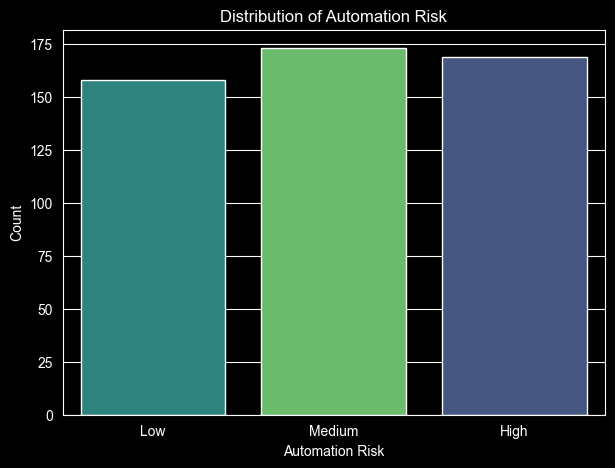

Automation_Risk
Medium    173
High      169
Low       158
Name: count, dtype: int64


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Automation Risk
plt.figure(figsize=(7, 5))
sns.countplot(x='Automation_Risk', data=df_clean, hue='Automation_Risk', palette='viridis', order=['Low', 'Medium', 'High'], legend=False)
plt.title('Distribution of Automation Risk')
plt.xlabel('Automation Risk')
plt.ylabel('Count')
plt.show()

print(df_clean['Automation_Risk'].value_counts())

### 3.2 Automation Risk Distribution by Industry (%)
A stacked bar chart showing the **proportional** distribution of automation risk across industries, allowing for a fairer comparison than raw counts.

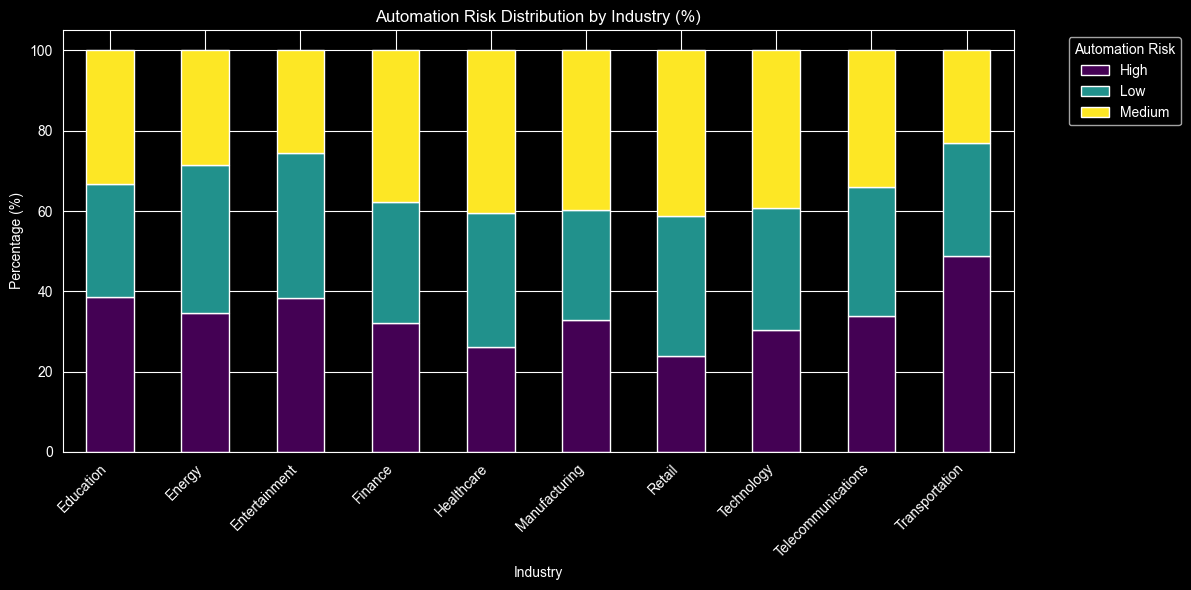

In [41]:
# Stacked bar chart - Automation Risk % by Industry
risk_industry = df_clean.groupby(['Industry', 'Automation_Risk']).size().unstack()
risk_industry_pct = risk_industry.div(risk_industry.sum(axis=1), axis=0) * 100

risk_industry_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Automation Risk Distribution by Industry (%)')
plt.xlabel('Industry')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Automation Risk', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### 3.3 Automation Risk by AI Adoption Level
We investigate whether companies with higher AI adoption levels tend to have more high-risk jobs. Intuitively, higher AI adoption should correlate with higher automation risk.

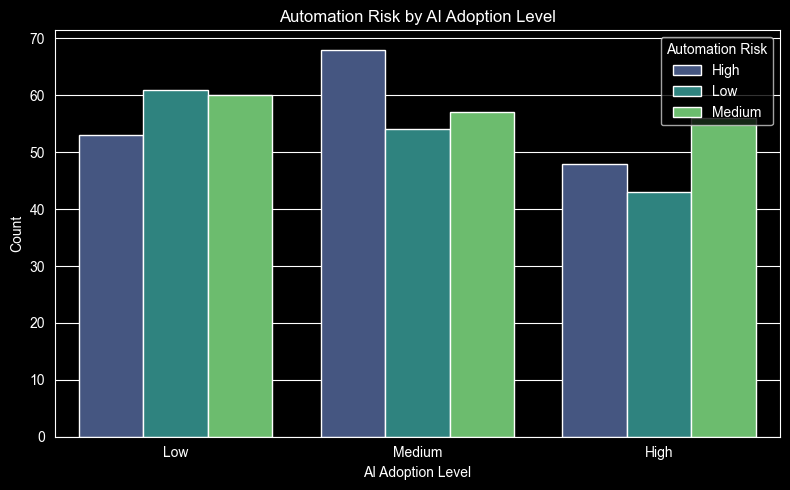

In [34]:
# Automation Risk by AI Adoption Level
plt.figure(figsize=(8, 5))
sns.countplot(x='AI_Adoption_Level', data=df_clean, hue='Automation_Risk', palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Automation Risk by AI Adoption Level')
plt.xlabel('AI Adoption Level')
plt.ylabel('Count')
plt.legend(title='Automation Risk')
plt.tight_layout()
plt.show()

### 3.4 Salary Distribution by Automation Risk
We examine whether salary levels differ across automation risk categories. Lower-paid jobs are generally more routine and therefore more susceptible to automation.

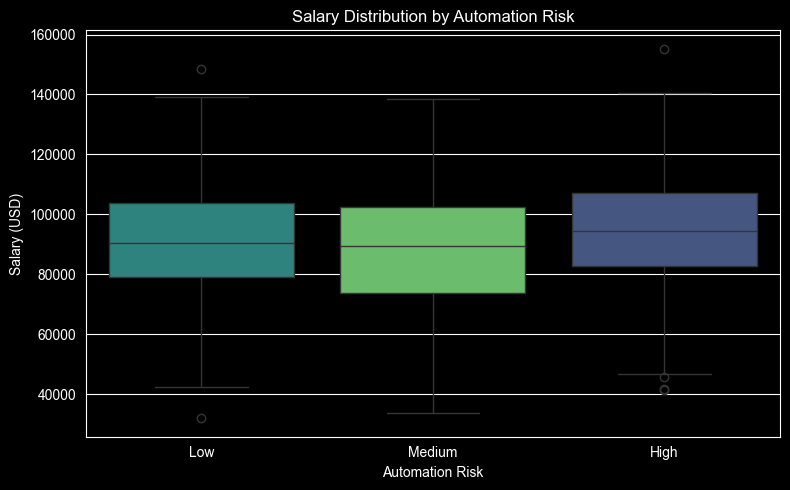

In [35]:
# Salary distribution by Automation Risk
plt.figure(figsize=(8, 5))
sns.boxplot(x='Automation_Risk', y='Salary_USD', data=df_clean, hue='Automation_Risk', palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Salary Distribution by Automation Risk')
plt.xlabel('Automation Risk')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

### 3.5 Automation Risk by Job Title
We explore which specific job roles carry the highest automation risk, directly addressing our research question about which jobs are most threatened by AI.

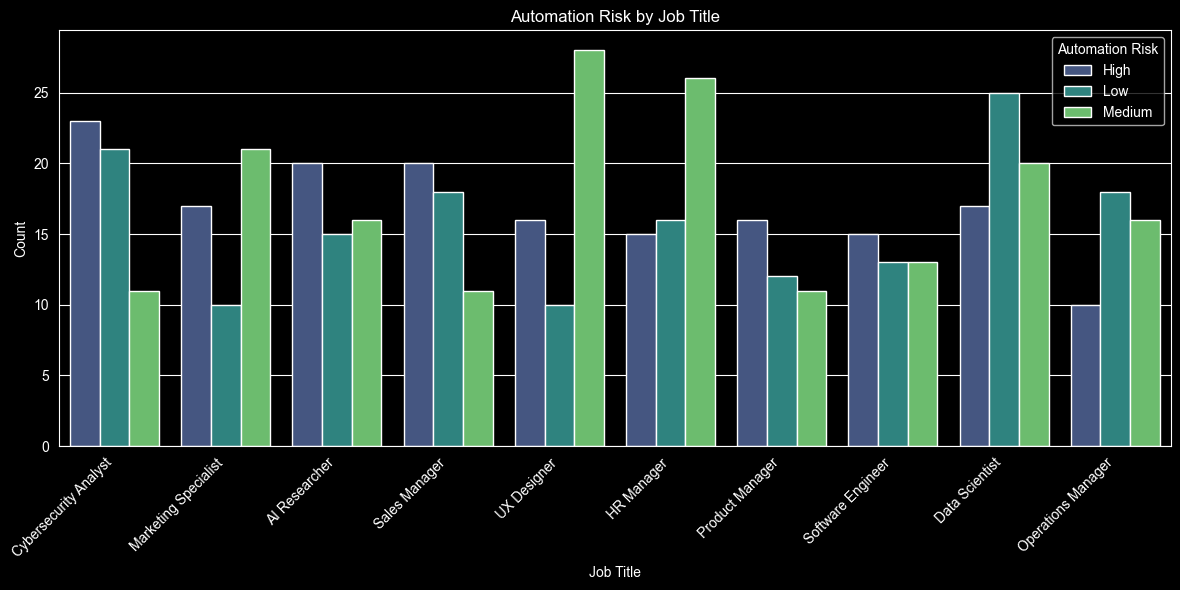

In [36]:
# Automation Risk by Job Title
plt.figure(figsize=(12, 6))
sns.countplot(x='Job_Title', data=df_clean, hue='Automation_Risk', palette='viridis')
plt.title('Automation Risk by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Automation Risk')
plt.tight_layout()
plt.show()

### 3.6 Feature Correlation with Automation Risk
A correlation heatmap is used to measure the linear relationship between each feature and the target variable. This provides an initial indication of which features may be most predictive.

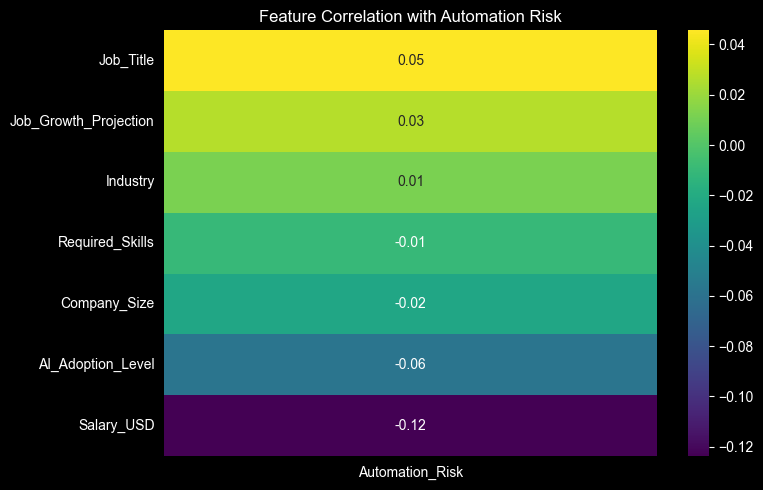

In [38]:
# Correlation with Automation_Risk only
plt.figure(figsize=(8, 5))
correlation = df_encoded.corr()[['Automation_Risk']].drop('Automation_Risk').sort_values('Automation_Risk', ascending=False)
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='viridis')
plt.title('Feature Correlation with Automation Risk')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Before training the models, the data needs to be transformed into a numerical format that machine learning algorithms can process.

### 4.1 Defining Features and Target
`Job_Title` and `Automation_Risk` are dropped from the feature matrix `X`. `Job_Title` is excluded as it was only used for EDA purposes, and `Automation_Risk` is our target variable `y`.

### 4.2 Encoding Categorical Features
All categorical features were encoded using **Label Encoding**, which converts each unique category into a numerical value.

### 4.3 Encoding Target Variable
The target variable `Automation_Risk` was also label encoded:

| Class | Encoded Value |
|---|---|
| High | 0 |
| Low | 1 |
| Medium | 2 |

The final feature matrix `X` contains **6 features** and **500 rows**:

`Industry`, `Company_Size`, `AI_Adoption_Level`, `Required_Skills`, `Salary_USD`, `Job_Growth_Projection`

In [42]:
from sklearn.preprocessing import LabelEncoder

# Define features and target
X = df_clean.drop(columns=['Automation_Risk', 'Job_Title'])
y = df_clean['Automation_Risk']

# Encode categorical features
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# Encode target variable
y = le.fit_transform(y)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nTarget classes:", le.classes_)

Features shape: (500, 6)
Target shape: (500,)

Feature columns: ['Industry', 'Company_Size', 'AI_Adoption_Level', 'Required_Skills', 'Salary_USD', 'Job_Growth_Projection']

Target classes: ['High' 'Low' 'Medium']


## 5. Model Training

### 5.1 Train/Test Split
The dataset is split into **80% training** and **20% testing** sets, resulting in 400 training samples and 100 test samples. A `random_state=42` is set for reproducibility.

In [43]:
from sklearn.model_selection import train_test_split

# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (400, 6)
Test set size: (100, 6)


### 5.2 Models
Three classification models are trained and compared:

| Model | Role |
|---|---|
| **Logistic Regression** | Baseline model — simple and interpretable |
| **Decision Tree** | Explainable model — visualizable decision rules |
| **Random Forest** | Ensemble model — highest accuracy + feature importance |

Each model is trained on `X_train` and evaluated on `X_test` using **Accuracy** and **weighted F1-Score**.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': accuracy, 'F1 Score': f1}
    print(f"{name}: Accuracy={accuracy:.2f}, F1={f1:.2f}")

Logistic Regression: Accuracy=0.32, F1=0.29
Decision Tree: Accuracy=0.30, F1=0.30
Random Forest: Accuracy=0.36, F1=0.36


### 5.3 Results

| Model | Accuracy | F1 Score |
|---|---|---|
| Logistic Regression | 0.32 | 0.29 |
| Decision Tree | 0.30 | 0.30 |
| **Random Forest** | **0.36** | **0.36** |

**Random Forest** outperforms the other models on both metrics. The overall low accuracy across all models is expected given the synthetic nature of the dataset, where feature-target relationships are weak as confirmed by the correlation analysis.

## 6. Evaluation

### 6.1 Confusion Matrices
A confusion matrix is plotted for each model to visualize how well each model predicts each class (High / Low / Medium). The diagonal represents correct predictions, while off-diagonal values represent misclassifications.

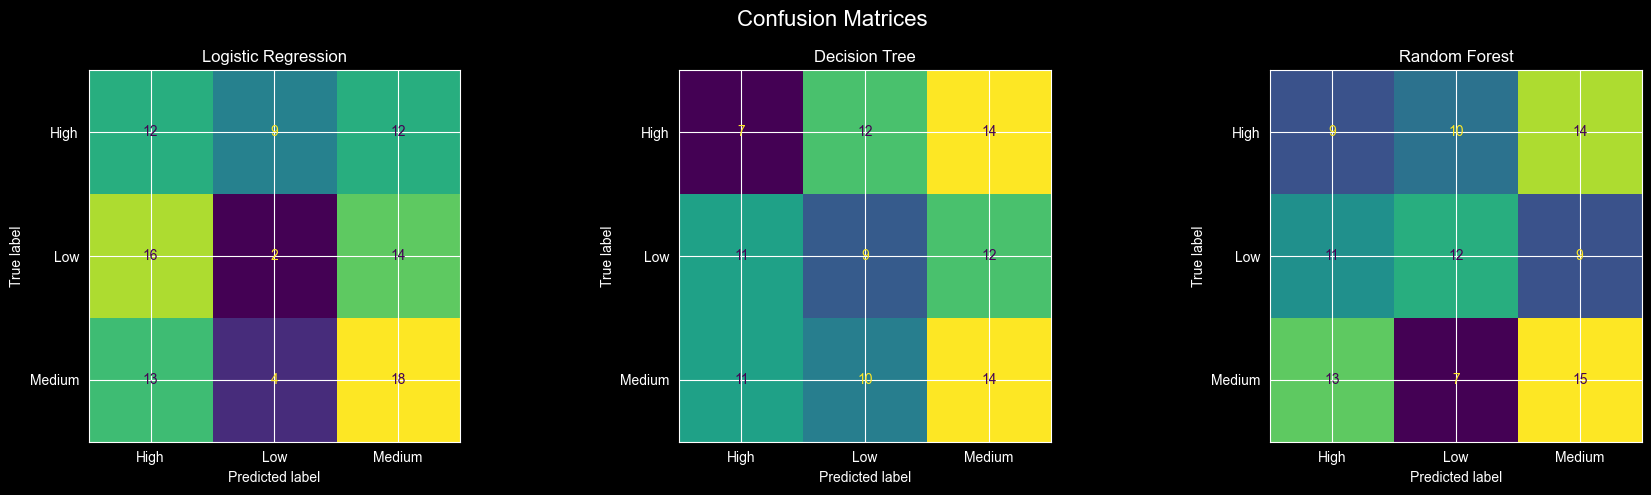

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low', 'Medium'])
    disp.plot(ax=ax, colorbar=False, cmap='viridis')
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

### 6.2 Model Comparison
A bar chart comparing **Accuracy** and **F1 Score** across all three models. Random Forest consistently outperforms the other two models on both metrics.

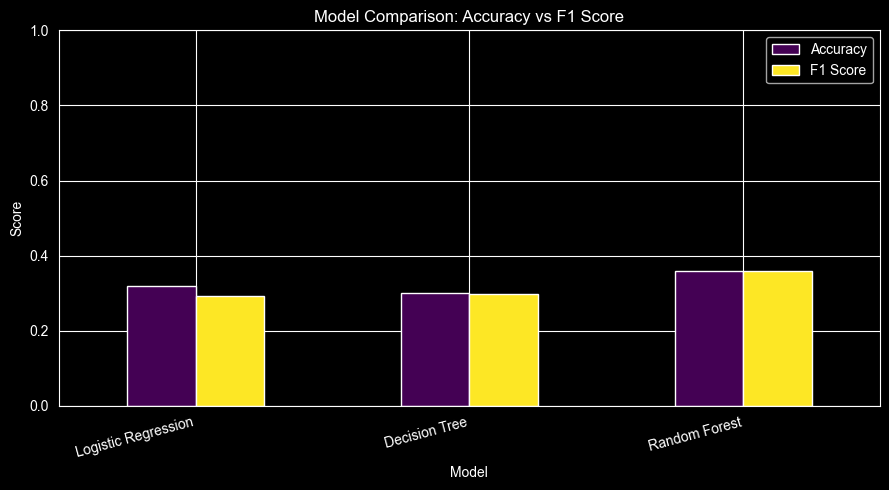

In [48]:
import pandas as pd

# Model comparison chart
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison: Accuracy vs F1 Score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 6.3 Feature Importance
Using the best performing model (**Random Forest**), we extract feature importance scores to answer our second research question — *which factor contributes the most to a job's automation risk?*

| Feature | Importance Score |
|---|---|
| `Salary_USD` | 0.35 |
| `Industry` | 0.20 |
| `Required_Skills` | 0.19 |
| `Job_Growth_Projection` | 0.13 |
| `AI_Adoption_Level` | 0.13 |
| `Company_Size` | 0.12 |

**Salary is the strongest predictor of automation risk**, followed by Industry and Required Skills. This aligns with real-world research showing that lower-paid routine jobs are most vulnerable to automation.

> **Note:** While the correlation heatmap suggested Salary had a weak linear relationship with automation risk (-0.12), Random Forest identified it as the most important feature — highlighting the non-linear nature of the relationship and the value of ML models over simple statistical measures.

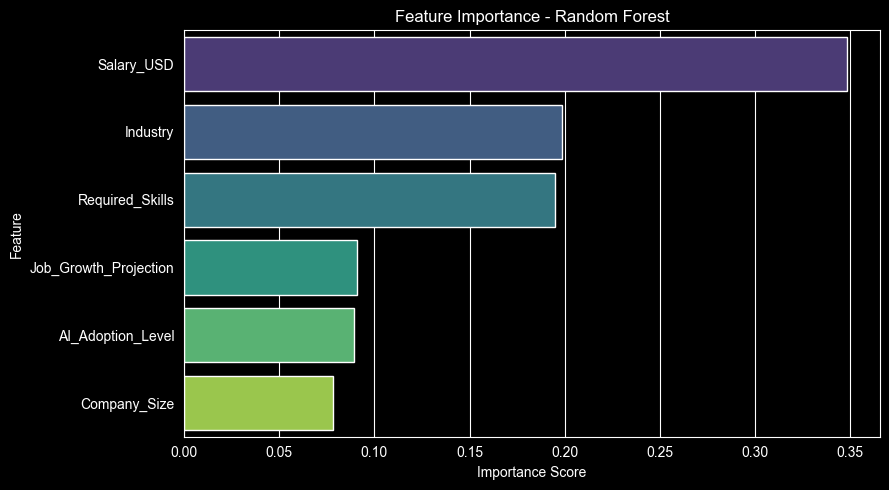

                 Feature  Importance
4             Salary_USD    0.348184
0               Industry    0.198651
3        Required_Skills    0.194935
5  Job_Growth_Projection    0.090897
2      AI_Adoption_Level    0.089202
1           Company_Size    0.078132


In [49]:
# Feature Importance from Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance)